/tmp/ipykernel_1304825/4174795145.py:34: RuntimeWarning: divide by zero encountered in divide
  term = -uijk * np.arctan(xi*yj / (zk*rijk))


GPU Max (B0=50000 nT): 7.9826e+01
Spatial Max (MATLAB units ?): 1.6051e+02
Ratio Spatial/GPU: 2.0107
Scaled MAE: 8.8959e-01


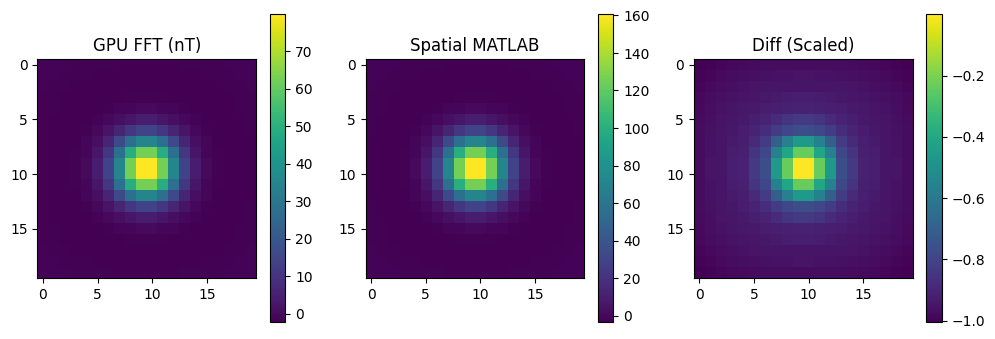

In [4]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt
import time
import sys
import importlib
sys.path.append("/home/wyh/wyhHDD/Project/GMESDataset/Magnetic/forward_modeling")
import mag_forward
importlib.reload(mag_forward)
from mag_forward import forward_mag_tmi

def mat_spatial_prism_magnetic(nx, ny, nz, dx, dy, dz, h, model_slice):
    x0 = np.arange(-(nx-1)*dx, (nx-1)*dx + 0.1, dx)
    y0 = np.arange(-(ny-1)*dy, (ny-1)*dy + 0.1, dy)
    z0_vals = np.arange(-(nz*dz+h), -(dz+h) + 0.1, dz)
    
    T_exact = np.zeros((2*nx-1, 2*ny-1, nz))
    Ai = [-dx/2, dx/2]
    Bj = [-dy/2, dy/2]
    Ck = [0, dz]
    
    for q in range(nz):
        zk_base = z0_vals[q]
        for i_idx, val_i in enumerate(Ai):
            for j_idx, val_j in enumerate(Bj):
                for k_idx, val_k in enumerate(Ck):
                    uijk = (-1)**((i_idx+1) + (j_idx+1) + (k_idx+1))
                    Y, X = np.meshgrid(y0, x0) 
                    xi = X + val_i
                    yj = Y + val_j
                    zk = zk_base + val_k
                    rijk = np.sqrt(xi**2 + yj**2 + zk**2)
                    term = -uijk * np.arctan(xi*yj / (zk*rijk))
                    T_exact[:, :, q] += term

    D = np.zeros((nx, ny))
    M = model_slice
    from scipy.signal import convolve2d
    for q in range(nz):
        layer_m = M[:, :, (nz - 1) - q] 
        layer_k = T_exact[:, :, q]
        
        conv_res = convolve2d(layer_k, layer_m, mode='valid')
        D += conv_res
        
    return D * 100.0

def compare_results():
    nx, ny, nz = 20, 20, 10
    dx, dy, dz = 100., 100., 100.
    model = np.zeros((nx, ny, nz))
    model[8:12, 8:12, 2:6] = 1.0 
    
    obs_conf = {"layout": "grid", "n_x": nx, "n_y": ny}
    
    # Run Python GPU Forward with standard Earth field
    B0_val = 50000.0
    
    tmi_gpu_t, meta = forward_mag_tmi(
        torch.from_numpy(model).float(), dx, dy, dz, 
        heights_m=[0], obs_conf=obs_conf, 
        B0=B0_val, I_deg=90, A_deg=0, output_unit="nt"
    )
    tmi_gpu = tmi_gpu_t[0, 0].cpu().numpy()
    
    d_spatial = mat_spatial_prism_magnetic(nx, ny, nz, dx, dy, dz, h=0, model_slice=model)
    
    print(f"GPU Max (B0={B0_val:.0f} nT): {tmi_gpu.max():.4e}")
    print(f"Spatial Max (MATLAB units ?): {d_spatial.max():.4e}")
    
    # Check if they are now in the same universe
    ratio = d_spatial.max() / tmi_gpu.max()
    print(f"Ratio Spatial/GPU: {ratio:.4f}")
    
    # If Ratio is close to 1, we nailed it.
    
    # If they are different by a factor (e.g. 100), it's units.
    # We plot normalized.
    
    scale_factor = ratio # Apply to GPU to match Spatial for plot
    
    diff = tmi_gpu * scale_factor - d_spatial
    mae = np.mean(np.abs(diff))
    print(f"Scaled MAE: {mae:.4e}")
    
    plt.figure(figsize=(12,4))
    plt.subplot(131); plt.imshow(tmi_gpu); plt.title("GPU FFT (nT)")
    plt.colorbar()
    plt.subplot(132); plt.imshow(d_spatial); plt.title("Spatial MATLAB")
    plt.colorbar()
    plt.subplot(133); plt.imshow(diff); plt.title("Diff (Scaled)")
    plt.colorbar()
    plt.show()

compare_results()